# Réseau de neurones : Multilayer perceptron

On va programmer, en Python, un réseau de neurones de type multilayer perceptron (MLP). Cette structure qui consiste en une succession de couches de neurones, effectuant chacun des opérations, peut apprendre des fonctions quelconques sans qu'on ai besoin de lui préciser leur définition mathématique.

Dans cet exercice, l'objectif est de faire apprendre la fonction sinus à un MLP sur un certain intervalle. Après la phase d'apprentissage, on veut donc que le réseau soit capable de nous renvoyer une très bonne approximation de la valeur du sinus d'un nombre qu'on lui donnera en entrée.

Dans la dernière partie, on effectuera d'autres tests pour vérifier le bon fonctionnement du réseau lorsqu'on modifie ses paramètres ou le nombre d'entrées et de sorties.

## Programmation du MLP

Comme indiqué précédamment, un MLP consiste en une suite de couches de neurones. *Python* étant un langage qui offre la possibilité d'une programmation orientée objet, on va naturellement employer cette approche et réfléchir à quels objets créer. On peut avoir envie de créer tout d'abord des neurones, qu'on regrouperait dans des couches, elles-mêmes regroupées dans le réseau. Cependant, traiter l'ensemble des neurones dans une couche comme un seul objet est plus intéressant que de les considérer individuellement. On choisit donc de ne faire que deux objets : couche et réseau.

La raison qui explique ce choix est que les opérations effectuées par les neurones peuvent être traitées avec des fonctions `numpy` pour certaines, et du calcul matriciel pour les autres, qui peut aussi être géré par `numpy`. Regrouper l'ensemble des données concernant les neurones dans des tableaux `numpy` de dimensions adéquates permettra d'effectuer des opérations sur les tableaux entiers, plutôt que d'utiliser les boucles `for` de *Python* pour itérer sur l'ensemble des neurones. Cette méthode accélérera la vitesse de calcul, en effet les opérations de `numpy` sont généralement beaucoup plus rapides que les boucles de *Python*.

### Code des objets couche et réseau

On choisit donc de créer deux classes d'objets, que l'on range dans les deux programmes suivants. On expliquera ensuite comment et pourquoi ont été définies les différentes fonctions.

#### `couche.py`

In [1]:
"""
Module pour la classe de couche de neurones.
"""

import numpy as np


class Couche:
    """
    Classe de couches de neurones
    """
    def __init__(self, n_neurones_coucheprec, n_neurones, f_activ, df_activ):
        self.n_neu = n_neurones # nb de neurones de la couche
        self.n_neup = n_neurones_coucheprec # nb de neurones de la couche précédente
        self.f = f_activ # fonction d'activation
        self.df = df_activ # derivée de la fonction d'activation

        # génération aléatoire de la matrice de poids (biais inclus)
        self.W = np.random.uniform(-1,1, (self.n_neu,self.n_neup+1))
        self.z = None # somme pondérée des sorties précédentes par les poids
        self.u = None # sorties de la couche actuelle
        self.u_n_1 = None # sorties de la couche précédente

        self.dL_dz = None # gradient par rapport à z
        self.dL_dW = np.zeros(self.W.shape) # gradient par rapport à W

        # paramètres pour l'optimizer
        self.m_t_1 = np.zeros(self.W.shape) # mémoire pour m_t
        self.v_t_1 = np.zeros(self.W.shape) # mémoire pour v_t
        # paramètres biaisés
        self.m_t = None
        self.v_t = None
        # paramètres corrigés
        self.mt = None
        self.vt = None


    def pass_forward(self, Yp):
        """
        Prend les sorties de la couche précédente, effectue leur somme pondérée
        par les poids (pour chaque neurone de la couche) et applique la
        fonction d'activation pour renvoyer les résultats.
        """
        self.z = np.matmul(
            self.W,
            np.concatenate([Yp.T, np.array([[1]*Yp.shape[0]])], axis=0)
        ).T
        self.u = self.f(self.z)
        return self.u


    def bp_init(self, valeur_att, N_batch, u_n_1):
        """
        Calcule les gradients pour la dernière couche :
        - calcule les gradients par rapport à z
        - en déduit les gradients par rapports à W
        """
        self.u_n_1 = np.concatenate([u_n_1,np.array([[1]]*N_batch)], axis=1)
        self.dL_dz = (2/N_batch) * (self.u - valeur_att) * self.df(self.z)
        self.dL_dW = np.tensordot(self.dL_dz, self.u_n_1, axes=([0],[0]))


    def back_propagation(self, N_batch, u_n_1, dL_dZ_n1, W_n1):
        """
        Calcule les gradients pour les couches (sauf la dernière) :
        - calcule les gradients par rapport à z
        - en déduit les gradients par rapport à W
        """
        self.u_n_1 = np.concatenate([u_n_1,np.array([[1]]*N_batch)], axis=1)
        self.dL_dz = self.df(self.z) * np.matmul(dL_dZ_n1, W_n1[:,:-1])
        # on ne prend pas en compte les biais de la couche suivante car ils ne
        # dépendent pas de la couche actuelle
        self.dL_dW = np.tensordot(self.dL_dz, self.u_n_1, axes=([0],[0]))


    def update_weights(self, type, learning_rate=0.001, learn_number=1, B1=0.9,
                       B2=0.999, e=1e-8):
        """
        Modifie les poids à partir des gradients de la loss function.
        - 'type' indique le type d'optimizer utilisé.
        - 'learning_rate' indique le taux d'apprentissage.
        - 'learn_number' indique le numéro d'apprentissage.
        - 'B1' et 'B2' sont liés aux paramètres calculés (taux d''oubli').
        - 'e' est utilisé pour éviter une possible division par zéro.

        On a différents optimizer possibles :
        - 'type' = 0 -> Implémentation de la descente de gradient classique,
        Batch Gradient Descent (BGD).
        - 'type' = 1 -> Implémentation de l'optimize Adaptative Moment
        Estimation (Adam).
        """
        if type == 0:
            # BATCH GRADIENT DESCENT
            self.W -= learning_rate * self.dL_dW

        if type == 1:
            # ADAM OPTIMIZER
            # paramètres biaisés
            self.m_t = B1*self.m_t_1 + (1-B1)*self.dL_dW
            self.v_t = B2*self.v_t_1 + (1-B2)*self.dL_dW**2
            # correction des paramètres (suppression des biais)
            self.mt = self.m_t/(1-B1**learn_number)
            self.vt = self.v_t/(1-B2**learn_number)
            # modification des poids
            self.W -= learning_rate * self.mt/(np.sqrt(self.vt) + e)
            # changement des paramètres en mémoire
            self.m_t_1 = self.m_t
            self.v_t_1 = self.v_t

#### `reseau.py`

In [2]:
"""
Module pour la classe de réseau.
"""

import numpy as np


class Reseau:
    """
    Classe de réseau qui contient plusieurs couches de neurones.

    Attend qu'on lui donne des objets de type 'Couche' du module 'couche' en
    entrée (sauf la première). Les fonctions de la classe ne fonctionneront pas
    si on lui donne des objets différents.

    'opt_type' définit l'optimizer utilisé (par défaut BGD) :
    - 0 pour Batch Gradient Descent (BGD).
    - 1 pour Adaptative Moment Estimation (Adam).
    """
    def __init__(self, opt_type, *couches):
        # regroupe les couches de neurones sous forme de liste
        self.couches = list(couches)
        self.nb_couches = len(self.couches) # nombre de couches
        self.N_batch = 1 # taille de batch
        self.lr = 1 # learning rate

        self.opt_type = opt_type # type d'optimizer
        self.learn_number = 0 # indique le nombre de fois qu'on a appris

        self.entries = None # entrées du réseau
        self.output = None # sortie du réseau
        self.loss_value = None # résultat de la loss function

        if type(self.opt_type) != int:
            raise ValueError("Préciser l'optimizer à utiliser.")


    def pass_forward(self, entries):
        """
        Fonction de pass forward qui prend les entrées du
        réseau et renvoie les prédictions de celui-ci.
        - 'self.output' correspond finalement à la prédiction du réseau.
        - Fonctionne avec plusieurs données a la fois :
        'entries' doit être de la forme [[donnees1], [donnees2], ...]
        (liste ou tableau numpy)
        """
        self.entries = np.array(entries) # sauvegarde les entrées
        self.N_batch = self.entries.shape[0] # actualise la taille de batch
        # initialise les données qui passent dans le réseau
        self.output = self.entries
        # fait "avancer" les données dans le réseau
        for couche in self.couches:
            self.output = couche.pass_forward(self.output)
        return self.output


    def loss(self, valeur_att):
        """
        Renvoie le résultat de la loss function (ici MSE) calculée sur le batch
        """
        valeur_att = np.array(valeur_att)
        self.loss_value = (1/self.N_batch)*np.sum((self.output-valeur_att)**2)
        return self.loss_value


    def back_propagation(self, valeur_att):
        """Effectue la back propagation dans le réseau : modifie les poids"""
        self.learn_number += 1 # on apprend une fois de plus

        # Calcul des gradients dans les différentes couches
        if self.nb_couches > 1:
            # calcul des gradients et modification des poids (dernière couche)
            self.couches[-1].bp_init(
                valeur_att, 
                self.N_batch, 
                self.couches[self.nb_couches -2].u
            )
            # calcul des gradients (hidden layers en partant de la fin)
            for i in range(self.nb_couches -2):
                self.couches[self.nb_couches -i -2].back_propagation(
                    self.N_batch,
                    self.couches[self.nb_couches -i -2 -1].u, 
                    self.couches[self.nb_couches -i -2 +1].dL_dz, 
                    self.couches[self.nb_couches -i -2 +1].W
                )
            # calcul des gradients (première couche)
            self.couches[0].back_propagation(
                self.N_batch,
                self.entries, 
                self.couches[1].dL_dz, 
                self.couches[1].W
            )
        else:
            self.couches[-1].bp_init(
                valeur_att, 
                self.N_batch, 
                self.entries
            )

        # Modification des poids
        for couche in self.couches:
            couche.update_weights(self.opt_type, self.lr, self.learn_number)

### Définition des fonctions

Les caractéristiques des deux types d'objets sont définies lors de la création des objets :
- Pour les couches, le nombre de neurones de la couche précédente est important car leurs sorties sont les données que vont traiter les neurones de la couche actuelle. Par ailleurs, on doit définir le nombre de neurones dans la couche, ainsi que la fonction d'activation des neurones, à partir de laquelle on obtient les sorties de la couche.
- Pour le réseau, on doit bien évidemment donner les couches du neurones successivement, et aussi le type d'optimizer (qu'on expliquera dans la partie correspondante).

#### Forward propagation

On s'intéresse tout d'abord à la forward propagation : on donne des valeurs au réseau, et il nous renvoie ses résultats.

La programmation de cette fonction se fait dans les fonctions `pass_forward` du réseau et des couches. Dans le réseau, la fonction prend les entrées, les donne à la première couche, récupère le résultat qu'elle donne en entrée de la couche suivante, et caetera, jusqu'à la dernière couche du réseau, puis renvoie les résultats.

C'est différent pour les couches. Deux opérations se succèdent dans chaque neurone d'une couche : tout d'abord une somme des sorties de la couche précédente (ou des entrées du réseau si c'est la première couche) pondérée par les poids du neurone (un par sortie de la couche précédente), puis l'application de la fonction d'activation au résultat. On obtient ainsi la sortie du neurone, pour chaque neurone de la couche. Les poids indiquent à quel point la sortie correspondante de la couche précédente est importante pour le neurone. Les poids sont différents pour chaque sortie précédente et chaque neurone.

On peut écrire la première étape comme ceci :
$$z_{j,i_b}^{(n)} = \sum_k W_{kj}^{(n)} u_{k,i_b}^{(n-1)}$$
où $z_{j,i_b}^{(n)}$ est la somme pondérée des sorties précédentes pour le neurone $j$ de la couche $n$. On reviendra plus tard sur l'indice $i_b$ qu'on devra cependant toujours prendre en compte. Les $u_{k,i_b}^{(n-1)}$ sont les sorties de la couche précédente, avec $k$ qui correspond au neurone $k$ de la couche précédente. $W_{kj}^{(n)}$ est le poids correspondant.

On se rend bien compte qu'on peut écrire ça sous forme matricielle, où on aura :
$$Z_{i_b}^{(n)} = W^{(n)} . U_{i_b}^{(n-1)}$$
avec les matrices correspondantes (W est la matrice de poids avec le nombre de neurones pour nombre de lignes et le nombre d'entrées +1 pour nombre de colonnes). C'est ce premier calcul qu'on fait dans la première ligne de la fonction `pass_forward` pour les couches. On n'oublie pas de rajouter un poids de biais dans la couche, et pour cela on ajoute un $1$ à la fin du vecteur $U$ en sortie de la couche précédente.

Le second calcul peut s'écrire :
$$u_{k,i_b}^{(n)} = f(z_{k,i_b}^{(n)})$$
avec $f$ la fonction d'activation du neurone qui va dire en quelque sorte à quel point le neurone aura d'importance pour la couche suivante, donc à quel point il "s'active". Avec les fonctions de `numpy` sur des tableaux, on peut écrire ça comme :
$$U_{i_b}^{(n)} = f(Z_{i_b}^{(n)})$$

Ainsi, on obtient les résultats de la couche que la fonction renvoie à la fin.

La forward propagation nous donne donc les résultats du réseau, qu'on peut récupérer. Mais ses résultats sont aléatoires au départ. En effet, on initialise la matrice de poids de chaque couche avec des valeurs aléatoires entre $-1$ et $1$. On doit à présent faire en sorte que le réseau puisse apprendre à renvoyer des résultats corrects.

#### Loss function

Mais avant de commencer à apprendre, il faut qu'on sache à quel point le réseau se trompe. Pour cela, on introduit une fonction d'erreur, `loss` dans le programme du réseau. Cette fonction quantifie l'erreur entre la prédiction du réseau et la valeur attendue.

On choisit ici la fonction MSE (mean squared error) qui s'exprime, pour un seul élément, sous cette forme, où $(f)$ indique la couche finale :
$$E = \sum_k (u_k^{(f)} - y_k)^2$$
où les $y_k$ sont les valeurs attendues pour chaque sortie $k$.

Le problème avec cette idée est qu'on n'apprend que sur une seule donnée à la fois : on envoie une donnée au réseau, on calcule l'erreur, et on apprend. Il est plus efficace d'apprendre sur plusieurs données en même temps dans le lot de données total : le batch. C'est pourquoi on a introduit plus tôt l'indice $i_b$ : il dit à quel élément du batch on s'intéresse. 

En effet, avec des tableaux de taille adéquate et en choisissant correctement les axes sur lesquels effectuer les opérations matricielles ou les fonctions, `numpy` permet de traiter l'entièreté des données d'un batch simutanément, ce qui accélère les calculs.

Ainsi, on peut adapter la fonction d'erreur pour la calculer en moyenne sur le batch :
$$\boxed{ E = \frac{1}{N_{batch}} \sum_{i_b = 1}^{N_{batch}} \sum_k (u_{k,i_b}^{(f)} - y_{k,i_b})^2 }$$
où $N_{batch}$ est le nombre de données dans le batch, soit la taille de batch.

À l'aide de cette fonction, on peut quantifier l'erreur du réseau et ainsi apprendre sur plusieurs données à la fois.

#### Backward propagation

La backward propagation est ce qui constitue l'apprentissage du réseau, et c'est la plus grande partie de l'implémentation de celui-ci.

Comme dit précédamment, les résultats de chaque couche dépendent des poids, et ainsi les résultats du MLP seront influencés par eux. L'apprentissage du réseau se fera donc en modifiant chacun de ces poids. L'objectif est de trouver les poids qui minimisent la fonction d'erreur pour que les résultats prédits par le réseau soient les plus proches possible des résultats attendus.

On a donc un problème de minimisation de la fonction d'erreur dans l'espace des poids du réseau. On va donc effectuer une descente de gradient dans cet espace vers le minimum global de $E$.

Le gradient indique la direction et le sens des plus hautes valeurs de la fonction, donc on doit modifier les poids dans le sens opposé. Si on note $W$ le vecteur de l'ensemble des poids du réseau, on aura, pour une descente de gradient classique :
$$W \rightarrow W - \alpha \overrightarrow{grad}_{W}E$$
soit, individuellement :
$$W_{ij}^{(n)} \rightarrow W_{ij}^{(n)} - \alpha \frac{\partial E}{\partial W_{ij}^{(n)}}$$
où $\alpha$ est le taux d'apprentissage (learning rate).

On a donc tout d'abord besoin de calculer les dérivées de la fonction d'erreur par rapport aux poids. On a :
$$\frac{\partial E}{\partial W_{ij}^{(n)}} = \sum_{i_b = 1}^{N_{batch}} \frac{\partial E}{\partial z_{j,i_b}^{(n)}} \frac{\partial z_{j,i_b}^{(n)}}{\partial W_{ij}^{(n)}}$$
et, puisque $\frac{\partial z_{j,i_b}^{(n)}}{\partial W_{ij}^{(n)}} = u_{i,i_b}^{(n-1)}$, on obtient finalement :
$$\boxed{ \frac{\partial E}{\partial W_{ij}^{(n)}} = \sum_{i_b = 1}^{N_{batch}} \frac{\partial E}{\partial z_{j,i_b}^{(n)}} u_{i,i_b}^{(n-1)} } \tag{1}$$
où les $u_{i,i_b}^{(n-1)}$ sont les sorties de la couche précédente, sauf pour la première couche pour laquelle ce sont directement les entrées du réseau.

Pour calculer les dérivées par rapport aux poids, on a donc besoin de calculer tout d'abord les dérivées par rapport aux sommes des entrées pondérées par les poids : les $z$. $\forall n \in [1; f-1]$, on a :
$$\frac{\partial E}{\partial z_{j,i_b}^{(n)}} = \sum_k \frac{\partial E}{\partial z_{k,i_b}^{(n+1)}} \frac{\partial z_{k,i_b}^{(n+1)}}{\partial z_{j,i_b}^{(n)}}$$
Or $z_{k,i_b}^{(n+1)} = \sum_l W_{lk}^{(n+1)} u_{l,i_b}^{(n)}$ où $u_{l,i_b}^{(n)} = f(z_{l,i_b}^{(n)})$ donc $\frac{\partial z_{k,i_b}^{(n+1)}}{\partial z_{j,i_b}^{(n)}} = W_{jk}^{(n+1)} f'(z_{j,i_b}^{(n)})$. On a finalement :
$$\boxed{ \frac{\partial E}{\partial z_{j,i_b}^{(n)}} = f'(z_{j,i_b}^{(n)}) \sum_k \frac{\partial E}{\partial z_{k,i_b}^{(n+1)}} W_{jk}^{(n+1)} } \tag{2}$$

Et on s'aperçoit ainsi que pour $n \not= f$, on peut exprimer les dérivées par rapport à $z$ de chaque couche dépendent des dérivées par rapport à $z$ de la couche suivante. C'est pourquoi on nomme cette étape back propagation : on va calculer les dérivées pour la dernière couche puis remonter petit à petit les couches du réseau en calculant les dérivées pour chacune d'entre elles à partir des calculs de la couche suivante.

On doit donc calculer en premier les dérvivées par rapport à $z$ pour la dernière couche. On a :
$$\frac{\partial E}{\partial z_{j,i_b}^{(f)}} = \frac{\partial}{\partial z_{j,i_b}^{(f)}}(\frac{1}{N_{batch}} \sum_{m = 1}^{N_{batch}} \sum_k (f(z_{k,m}^{(f)}) - y_{k,m})^2)$$
donc :
$$\frac{\partial E}{\partial z_{j,i_b}^{(f)}} = \frac{2}{N_{batch}} (f(z_{j,i_b}^{(f)}) - y_{j,i_b}) f'(z_{j,i_b}^{(f)})$$
Généralement on pose $f = Id$ pour la dernière couche : le résultat du réseau est une combinaison linéaire des résultats de l'avant-dernière couche. On a finalement :
$$\boxed{ \frac{\partial E}{\partial z_{j,i_b}^{(f)}} = \frac{2}{N_{batch}} (z_{j,i_b}^{(f)} - y_{j,i_b}) } \tag{3}$$

On peut donc calculer toutes les dérivées qui nous intéressent.

Dans la classe `reseau`, on implémente cette méthode dans la fonction `back_propagation` : on calcule tout d'abord les dérivées pour la dernière couche, puis on remonte jusqu'à la première couche.

Dans la classe `couche`, on programme les calculs dans les fonctions `bp_init` (pour la dernière couche) et `back_propagation` (pour les autres couches) :
- dans `bp_init`, on utilise l'équation $(3)$ pour calculer les dérivées de la fonction d'erreur par rapport aux $z$, puis on utilise la fonction `tensordot` de `numpy` pour appliquer l'équation $(1)$ et calculer les dérivées par rapport aux poids.
- dans `back_propagation`, la deuxième étape est la même. La première est modifiée : on prend en entrée les dérivées par rapport aux $z$ de la couche suivante pour appliquer l'équation $(2)$.

Lorsqu'on a calculé les dérivées pour toutes les couches, on appelle dans la classe `reseau` la fonction `update_weights` pour chacune des couches, ce qui actualise les poids : le réseau apprend.

#### Optimizer

Pour l'apprentissage, on séparera le lot de données d'entraînement en batch, et on entraînera le réseau plusieurs fois sur tous les batch, soit sur plusieurs epoch. Cependant, la méthode classique de descente de gradient risque d'être peu efficace si la surface représentative de la fonction d'erreur dans l'espace des poids présente des points selle ou des minima locaux. Le learning rate étant constant, on aura par ailleurs un ralentissement de la descente de gradient, et donc de l'apprentissage, en se rapprochant d'un minimum. Afin de régler ces problèmes, on va modifier la méthode de descente classique (**BGD**) en implémentant un optimizer qui va optimiser la descente de gradient, la rendant plus rapide et capable de dépasser les problèmes tels que les points selle et les minima locaux. On va ainsi programmer l'optimizer **Adam**.

Deux types d'optimizer sont utilisés pour régler ces problèmes, et ils sont tous les deux basés sur la mise en mémoire des dérivées obtenues lors de l'apprentissage précédent :
- d'un côté, une amélioration de la **BGD** pour donner une certaine "inertie" à la descente, **BGD** avec momentum. Cette méthode permet notamment de dépasser les possibles minima locaux.
- de l'autre, un algorithme appelé **RMSProp** qui modifie la direction de la descente de gradient en considérant que, plus on a déjà avancé dans une certaine direction, moins on a encore besoin d'avancer dans cette direction, et inversement. L'algorithme est fait de sorte à ce que les dérivées plus anciennes en mémoire sont moins importantes que les plus récentes. **RMSProp** permet alors d'explorer les directions qui le sont moins, et ainsi de dépasser rapidement les points selle.

**Adam** est en quelque sorte une association des deux méthodes précédentes qui présente tout leurs avantages. On pose au départ toutes les données en mémoire à $0$ (le gradient est le vecteur nul avant l'apprentissage), et à chaque étape d'apprentissage $t$, pour tout poids $W$ :
- On calcule les deux paramètres :
    - $m_t = \beta_1 m_{t-1} + (1-\beta_1) \frac{\partial E}{\partial W}$
    - $v_t = \beta_2 v_{t-1} + (1-\beta_2) (\frac{\partial E}{\partial W})^2$
- Leurs valeurs tendent à rester très proches de $0$ (en effet, on pose généralement $\beta_1$ et $\beta_2$ très proches de $1$), alors on corrige ce biais en calculant :
    - $\^m_t = \frac{m_t}{(1-\beta_1^t)}$
    - $\^v_t = \frac{v_t}{(1-\beta_2^t)}$
- On modifie les poids :
$$\boxed{ W \rightarrow W - \alpha \frac{\^m_t}{\sqrt{\^v_t} + \epsilon} } \tag{4}$$

Et on pose généralement :
- $\alpha = 0.001$ le learning rate.
- $\beta_1 = 0.9$ un taux de perte de mémoire pour le premier paramètre.
- $\beta_2 = 0.999$ un taux de perte de mémoire pour le second paramètre.
- $\epsilon = 10^{-8}$ qui permet d'éviter une potentielle division par $0$ lorsqu'on actualise les poids.

On voit l'influence des deux méthodes citées précédamment dans l'équation $(4)$. Le paramètre $\^m_t$ correspond au momentum : on fait en quelque sorte la somme des dérivées passées et de la dérivée actuelle, chacune ayant une certaine importance, ce qui donne une inertie à la descente de gradient. Le paramètre $\^v_t$ correspond à **RMSProp** : on fait cette fois la somme des carrés des dérivées passées et actuelle, et on prend ensuite la racine du résultat par laquelle on divise $\^m_t$ lors de la modification des poids. Cette division par la norme modifiée (par les dérivées en mémoire) de la dérivée par rapport à ce poids permet de modifier de manière plus importante un poids qui ne l'a pas été avant, et moins importante pour un poids qui a déjà été modifié.

On implémente ainsi **Adam** dans la fonction `update_weights` de la classe couche, tout en laissant la possibilité de choisir une descente classique si on le souhaite, et on fini de programmer le MLP en initialisant chaque paramètre des classes dans leur fonction `__init__`.

## Définition de fonctions

On aura besoin de certaines fonctions pour définir le réseau et traiter les données. C'est ici qu'on les définit :

#### `fonctions.py`

In [3]:
"""
Module pour les fonctions importantes :
- fonctions d'activation des neurones.
- fonctions de génération et traitement des données.
"""

import numpy as np
import scipy.stats as sc


### Fonctions d'activation ####################################################
# RELU
def ReLU(x):
    """Fonction ReLU"""
    return np.maximum(0,x)
def dReLU(x):
    """Derivée de la fonction ReLU (=0 si x<0 et =1 si x>0)"""
    return (x > 0) * np.ones(x.shape)

# IDENTITÉ
def Id(x):
    """Renvoie son entrée"""
    return x
def dId(x):
    """Dérivée de x par rapport à x, soit 1"""
    return np.ones(x.shape)

# TANH
def tanh(x):
    """Fonction tangente hyperbolique"""
    return np.tanh(x)
def dtanh(x):
    """Dérivée de la tangente hyperbolique"""
    return 1-np.tanh(x)**2
###############################################################################


### Fonctions de génération et traitement des données #########################
def generation(x, erreur=0, fonction=np.sin):
    """
    Génère des données suivant la fonction 'fonction' avec le bruit 'erreur'
    """
    Y = fonction(x)
    y = np.empty(x.shape)
    for i in range(y.size):
        y[i] = sc.norm.rvs()*erreur + Y[i]
    return y


def lots_donnees_reg(prop_test, taille_de_batch, *donnees):
    """
    Renvoie un tableau de taille (nb_batch, taille_de_batch, nb_entrees).

    Sépare les données de test et d'entraînement en fonction de :
    - 'prop_test' qui indique la proportion (minimale) de données de test dans
    les données totales.
    - 'taille_de_batch' qui indique la taille du batch.
    - '*donnees' qui est l'ensemble des données.

    La fonction attend de recevoir un tableau de données par entrée du réseau.

    Classe les données d'entraînement régulièrement par batch.
    Exemple : données = [1,2,3,4,5,6] -> [[1,3,5], [2,4,6]] (taille de batch 3)
    """
    donnees = list(donnees) # liste des tableaux d'entrées
    nb_entrees = len(donnees) # nombre de neurones de la première couche
    # mise en forme des entrées
    for i in range(len(donnees)):
        donnees[i] = np.reshape(donnees[i], (donnees[0].size,1))
    donnees = np.concatenate(donnees, axis=1) # un tableau pour les données

    # tirage aléatoire des données de test et d'entraînement
    # On prend une proportion prop_test de données de test dans les
    # données, et on y ajoute les données en trop dans ce qui reste.
    test_indices = np.random.choice(
        donnees.shape[0],
        size=(int(prop_test*donnees.shape[0]+((1-prop_test)*donnees.shape[0])%taille_de_batch)),
        replace=False
    )
    lot_ent_indices = np.setdiff1d(np.arange(donnees.shape[0]), test_indices)
    # séparation des données de test et d'entraînement
    test = donnees[test_indices]
    lot_ent = donnees[lot_ent_indices]

    if lot_ent.size == 0: # on vérifie qu'on ne renverra pas de tableau vide
        raise ValueError(
            "Pas assez de données envoyées par rapport à la taille de batch."
        )

    # mise en forme des données d'entraînement
    nb_batch = int(lot_ent.shape[0]/taille_de_batch)
    lot_ent = np.reshape(lot_ent.T, (nb_entrees, taille_de_batch, nb_batch)).T

    return lot_ent, test


def lots_donnees_aleat(prop_test, taille_de_batch, *donnees):
    """
    Renvoie un tableau de taille (nb_batch, taille_de_batch, nb_entrees).

    Sépare les données de test et d'entraînement en fonction de :
    - 'prop_test' qui indique la proportion (minimale) de données de test dans
    les données totales.
    - 'taille_de_batch' qui indique la taille du batch.
    - '*donnees' qui est l'ensemble des données.

    La fonction attend de recevoir un tableau de données par entrée du réseau.

    Classe les données d'entraînement aléatoirement.
    """
    donnees = list(donnees) # liste des tableaux d'entrées
    nb_entrees = len(donnees) # nombre de neurones de la première couche
    # mise en forme des entrées
    for i in range(len(donnees)):
        donnees[i] = np.reshape(donnees[i], (donnees[0].size,1))
    donnees = np.concatenate(donnees, axis=1) # un tableau pour les données

    # tirage aléatoire des données de test et d'entraînement
    # On prend une proportion prop_test de données de test dans les
    # données, et on y ajoute les données en trop dans ce qui reste.
    np.random.shuffle(donnees) # on classe les données aléatoirement
    taille_test = int(prop_test*donnees.shape[0]+((1-prop_test)*donnees.shape[0])%taille_de_batch)
    test = donnees[:taille_test] # les premières valeurs correspondent au test
    lot_ent = donnees[taille_test:] # le reste, aux données d'entraînement

    if lot_ent.size == 0: # on vérifie qu'on ne renverra pas de tableau vide
        raise ValueError(
            "Pas assez de données envoyées par rapport à la taille de batch."
        )

    # mise en forme des données d'entraînement
    nb_batch = int(lot_ent.shape[0]/taille_de_batch)
    lot_ent = np.reshape(lot_ent, (nb_batch, taille_de_batch, nb_entrees))

    return lot_ent, test
###############################################################################

On définit tout d'abord les fonctions d'activation **ReLU**, **identité** et **tangente hyperbolique**. Ensuite, on crée une fonction `generation` qui nous permet de générer des données potentiellement bruitées suivant une certaine fonction. Enfin, les fonctions `lots_donnees_reg` et `lots_donnees_aleat` sont faites pour classer les données par batch, respectivement régulièrement et aléatoirement. Par ailleurs, cette fonction sépare les données de test et d'entraînement, qu'on verra lors de la prochaine partie.

## Apprentissage de la fonction sinus

Maintenant qu'on a définit de manière générale toutes les classes et fonctions dont on a besoin, on peut créer et paramétrer le réseau qui devra apprendre la fonction sinus.

On commence par définir les paramètres de l'entraînement :

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# paramètres d'entraînement
nb_epoch = 200
taille_de_batch = 100
prop_test = 0.3 # proportion de données d'entraînement dans les données complètes
erreur_ent = []
erreur_test = []
f_acti = tanh
df_acti = dtanh

On choisit une proportion minimum de $30 \%$ de données de test parmi les données complètes, soit $70 \%$ de données d'entraînement au maximum. En effet, les données de test vont nous permettre de nous assurer que le réseau ne fait pas d'overfitting sur les données d'entraînement. Par ailleurs, c'est un pourcentage minimal car si on a finalement trop de données dans le lot d'entraînement par rapport à la taille de batch, on transformera le surplus en données de test.

On prend comme fonction d'activation la fonction tangente hyperbolique. Par ailleurs, on choisit une taille de batch de $100$ pour apprendre sur $100$ données à la fois.

On crée les listes `erreur_ent` et `erreur_test` pour conserver en mémoire l'évolution de l'erreur en fonction de l'entraînement pour les données d'entraînement et de test.

On peut à présent générer le lot de données complet, séparer les données de test et d'entraînement, et mettre en forme les tableaux de données.

On choisit de générer $1000$ données, non bruitées, suivant la fonction sinus, et réparties aléatoirement dans les batch.

In [5]:
# génération des données
nb_donnees = 1000
x = np.linspace(-10,10,nb_donnees) # ensemble des données
y = generation(x, erreur=0, fonction=np.sin) # objectif

# séparation des lots d'entraînement et de test
lot_ent, test = lots_donnees_aleat(prop_test, taille_de_batch, x, y)
lot_ent_x = lot_ent[:,:,0:1]
lot_ent_sinx = lot_ent[:,:,1:2]
test_x = test[:,0:1]
test_sinx = test[:,1:2]

La variable `lot_ent_x` contient les données $x$ de l'entraînement, à entrer dans le réseau pour obtenir ses prédictions, tandis que la variable `lot_ent_sinx` contient les résultats attendus correspondants et sur lesquels le réseau apprendra. Les données de test en revanche seront seulement utilisées pour étudier l'évolution de l'erreur dessus et ne compteront pas dans l'apprentissage.

À présent, définissons le réseau. On choisit une première couche de $20$ neurones, une seconde de $10$, et la dernière avec un seul pour avoir une seule sortie.

In [6]:
# définition du réseau
net = Reseau(
    1,
    Couche(1,20,f_acti, df_acti),
    Couche(20,10,f_acti, df_acti),
    Couche(10,1,Id, dId)
)
net.lr = 0.01

On choisit par ailleurs l'optimizer $1$, qui correspond à **Adam**. Pour toutes les couches, on a choisi la fonction tangente hyperbolique comme fonction d'activation, sauf pour la dernière où on pose la fonction identité comme précisé plus tôt.

On décide de prendre un learning rate de 0.01.

On peut à présent passer à l'apprentissage. Pour chaque epoch, le réseau apprend sur tous les batch. On calcule tout d'abord la prédiction du réseau sur les données de test et on enregistre l'erreur sur le résultat dans la liste `erreur_test`. Ensuite, on fait la même chose avec les données d'entraînement dans le batch, et on apprend ensuite sur ces données.

In [7]:
# Entraînement
for epoch in range(nb_epoch): # EPOCH
    for batch in range(lot_ent.shape[0]): # BATCH
        # test
        net.pass_forward(test_x)
        erreur_test.append(net.loss(test_sinx))
        # entraînement
        net.pass_forward(lot_ent_x[batch])
        erreur_ent.append(net.loss(lot_ent_sinx[batch]))
        net.back_propagation(lot_ent_sinx[batch])

Une fois l'entraînement terminé, on calcule la moyenne des erreurs sur l'epoch pour étudier l'évolution en fonction de l'epoch.

In [8]:
# calcul de l'erreur moyenne par epoch
erreur_test = np.array(erreur_test)
erreur_test = np.reshape(erreur_test, (nb_epoch, int(len(erreur_test)/nb_epoch)))
erreur_test = np.sum(erreur_test, axis=1)/nb_epoch
erreur_ent = np.array(erreur_ent)
erreur_ent = np.reshape(erreur_ent, (nb_epoch, int(len(erreur_ent)/nb_epoch)))
erreur_ent = np.sum(erreur_ent, axis=1)/nb_epoch

On peut ainsi étudier l'évolution de l'erreur durant l'apprentissage :

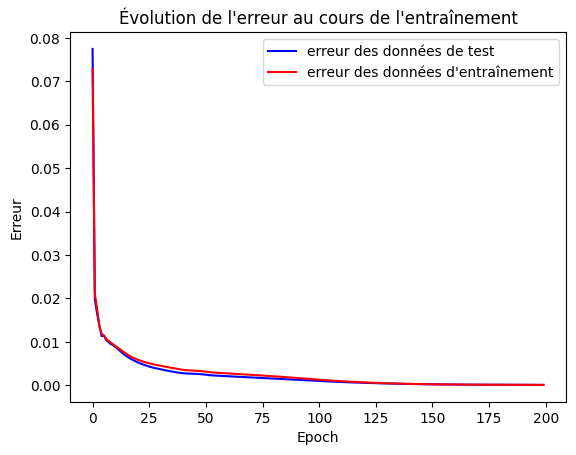

In [9]:
plt.plot(erreur_test, "b", label="erreur des données de test")
plt.plot(erreur_ent, "r", label="erreur des données d'entraînement")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Erreur")
plt.title("Évolution de l'erreur au cours de l'entraînement")
plt.show()

On remarque une forte décroissance de l'erreur au départ, ce à quoi on pouvait s'attendre car les dérivées par rapport aux poids sont plus importantes si on est plus loin du minimum global.

On peut aussi représenter graphiquement la prédiction du réseau par rapport aux données d'entraînement :

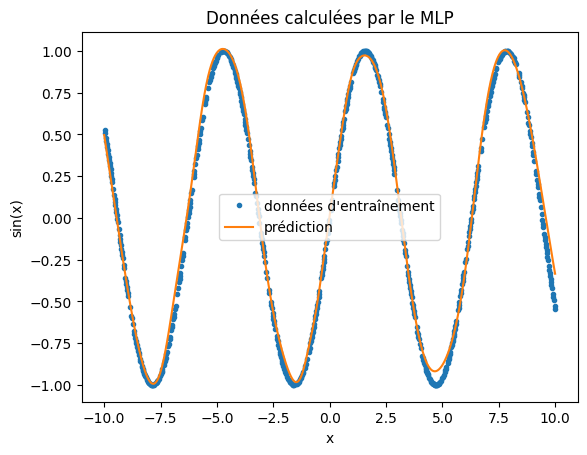

In [10]:
# calcul du résultat attendu
x = np.reshape(x, (x.size,1))
y_pred = net.pass_forward(x) # résultat du réseau

# Affichage des résultats
plt.plot(lot_ent_x.flatten(),lot_ent_sinx.flatten(),".", label="données d'entraînement")
plt.plot(x,y_pred,"-", label="prédiction")
plt.legend()
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Données calculées par le MLP")
plt.show()

On a ainsi un bon résultat pour l'apprentissage après $200$ epoch : le réseau a su apprendre assez correctement la fonction sinus dans l'intervalle $[-10,10]$.

## Pour aller plus loin

### Comparaison **BGD** / **Adam**

On peut à présent s'intéresser à la différence de résultats entre les deux types de descente de gradient : **BGD** ou **Adam**. Pour cela, on conserve les mêmes paramètres (même nombre d'epoch, même taille de batch, même données, ...) et on entraîne deux réseaux différents : l'un avec **BGD** et l'autre avec **Adam** :

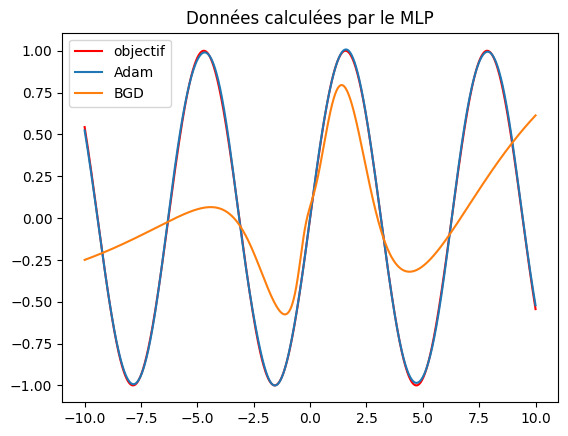

In [11]:
import numpy as np
import matplotlib.pyplot as plt


# paramètres d'entraînement
nb_epoch = 200
taille_de_batch = 100
prop_test = 0.3 # proportion de données d'entraînement dans les données complètes
erreur_ent = []
erreur_test = []
f_acti = tanh
df_acti = dtanh


# génération des données
nb_donnees = 1000
x = np.linspace(-10,10,nb_donnees) # ensemble des données
y = np.sin(x) # objectif

# séparation des lots d'entraînement et de test
lot_ent, test = lots_donnees_aleat(prop_test, taille_de_batch, x, y)
lot_ent_x = lot_ent[:,:,0:1]
lot_ent_sinx = lot_ent[:,:,1:2]
test_x = test[:,0:1]
test_sinx = test[:,1:2]

# définition du réseau
net = Reseau(
    1,
    Couche(1,20,f_acti, df_acti),
    Couche(20,10,f_acti, df_acti),
    Couche(10,1,Id, dId)
)
net.lr = 0.01


# Entraînement
for epoch in range(nb_epoch): # EPOCH
    for batch in range(lot_ent.shape[0]): # BATCH
        # test
        net.pass_forward(test_x)
        erreur_test.append(net.loss(test_sinx))
        # entraînement
        net.pass_forward(lot_ent_x[batch])
        erreur_ent.append(net.loss(lot_ent_sinx[batch]))
        net.back_propagation(lot_ent_sinx[batch])


# PLOT
# calcul du résultat attendu
x = np.reshape(x, (x.size,1))
y = np.reshape(y, (y.size,1)) # résultat attendu
plt.plot(x,y,"r-", label="objectif")


y_pred = net.pass_forward(x) # résultat du réseau

# Affichage des résultats
plt.plot(x,y_pred,"-", label="Adam")



# définition du réseau
net2 = Reseau(
    0,
    Couche(1,20,f_acti, df_acti),
    Couche(20,10,f_acti, df_acti),
    Couche(10,1,Id, dId)
)
net2.lr = 0.001


# Entraînement
for epoch in range(nb_epoch): # EPOCH
    for batch in range(lot_ent.shape[0]): # BATCH
        # test
        net2.pass_forward(test_x)
        erreur_test.append(net2.loss(test_sinx))
        # entraînement
        net2.pass_forward(lot_ent_x[batch])
        erreur_ent.append(net2.loss(lot_ent_sinx[batch]))
        net2.back_propagation(lot_ent_sinx[batch])


# PLOT
# calcul du résultat attendu
x = np.reshape(x, (x.size,1))
y = np.reshape(y, (y.size,1)) # résultat attendu
y_pred = net2.pass_forward(x) # résultat du réseau

# Affichage des résultats
plt.plot(x,y_pred,"-", label="BGD")


plt.legend()
plt.title("Données calculées par le MLP")
plt.show()

Et on remarque ainsi que $200$ epoch suffisent au réseau apprenant avec **Adam** pour obtenir un résultat excellent, contrairement au réseau avec **BGD** qui donne un mauvais résultat.

Cela nous permet de confirmer que l'optimizer **Adam** est bien plus efficace qu'une simple descente de gradient.

### Changement de paramètres

#### Ajout de bruit

On peut essayer de changer certains paramètres de l'apprentissage pour voir comment celui-ci est perturbé.

On commence par ajouter du bruit sur les données : on choisit des valeurs aléatoires suivant une loi normale d'écart-type $0.2$ pour le bruit à ajouter aux données.

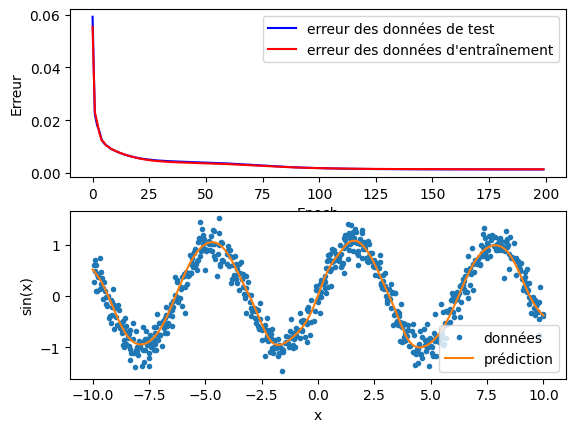

In [12]:
import numpy as np
import matplotlib.pyplot as plt


# paramètres d'entraînement
nb_epoch = 200
taille_de_batch = 100
prop_test = 0.3 # proportion de données d'entraînement dans les données complètes
erreur_ent = []
erreur_test = []
f_acti = tanh
df_acti = dtanh

# génération des données
nb_donnees = 1000
x = np.linspace(-10,10,nb_donnees) # ensemble des données
y = generation(x, erreur=0.2, fonction=np.sin) # objectif

# séparation des lots d'entraînement et de test
lot_ent, test = lots_donnees_aleat(prop_test, taille_de_batch, x, y)
lot_ent_x = lot_ent[:,:,0:1]
lot_ent_sinx = lot_ent[:,:,1:2]
test_x = test[:,0:1]
test_sinx = test[:,1:2]

# définition du réseau
net = Reseau(
    1,
    Couche(1,20,f_acti, df_acti),
    Couche(20,10,f_acti, df_acti),
    Couche(10,1,Id, dId)
)
net.lr = 0.01

# Entraînement
for epoch in range(nb_epoch): # EPOCH
    for batch in range(lot_ent.shape[0]): # BATCH
        # test
        net.pass_forward(test_x)
        erreur_test.append(net.loss(test_sinx))
        # entraînement
        net.pass_forward(lot_ent_x[batch])
        erreur_ent.append(net.loss(lot_ent_sinx[batch]))
        net.back_propagation(lot_ent_sinx[batch])

# calcul de l'erreur moyenne par epoch
erreur_test = np.array(erreur_test)
erreur_test = np.reshape(erreur_test, (nb_epoch, int(len(erreur_test)/nb_epoch)))
erreur_test = np.sum(erreur_test, axis=1)/nb_epoch
erreur_ent = np.array(erreur_ent)
erreur_ent = np.reshape(erreur_ent, (nb_epoch, int(len(erreur_ent)/nb_epoch)))
erreur_ent = np.sum(erreur_ent, axis=1)/nb_epoch

plt.subplot(2,1,1)
plt.plot(erreur_test, "b", label="erreur des données de test")
plt.plot(erreur_ent, "r", label="erreur des données d'entraînement")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Erreur")

# calcul du résultat attendu
x = np.reshape(x, (x.size,1))
y_pred = net.pass_forward(x) # résultat du réseau

# Affichage des résultats
plt.subplot(2,1,2)
plt.plot(lot_ent_x.flatten(),lot_ent_sinx.flatten(),".", label="données")
plt.plot(x,y_pred,"-", label="prédiction")
plt.legend()
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.show()

On s'aperçoit que le réseau parvient tout de même à apprendre la forme de la fonction sinus, mais moins bien que sur des données sans bruit.

#### Changement de la fonction d'activation 

On peut aussi tenter de modifier la fonction d'activation des neurones, remplacer la tengente hyperbolique par la fonction ReLU :

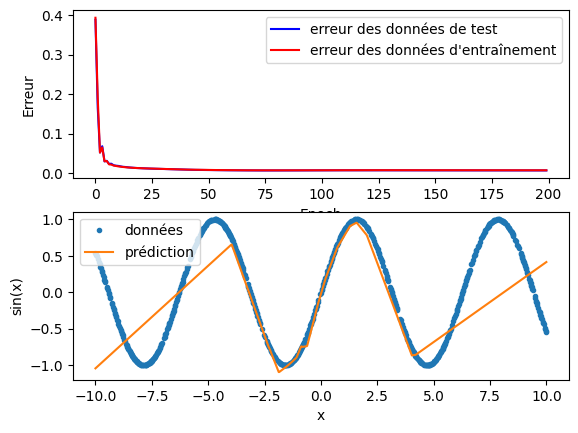

In [13]:
import numpy as np
import matplotlib.pyplot as plt


# paramètres d'entraînement
nb_epoch = 200
taille_de_batch = 100
prop_test = 0.3 # proportion de données d'entraînement dans les données complètes
erreur_ent = []
erreur_test = []
f_acti = ReLU
df_acti = dReLU

# génération des données
nb_donnees = 1000
x = np.linspace(-10,10,nb_donnees) # ensemble des données
y = generation(x, erreur=0, fonction=np.sin) # objectif

# séparation des lots d'entraînement et de test
lot_ent, test = lots_donnees_aleat(prop_test, taille_de_batch, x, y)
lot_ent_x = lot_ent[:,:,0:1]
lot_ent_sinx = lot_ent[:,:,1:2]
test_x = test[:,0:1]
test_sinx = test[:,1:2]

# définition du réseau
net = Reseau(
    1,
    Couche(1,20,f_acti, df_acti),
    Couche(20,10,f_acti, df_acti),
    Couche(10,1,Id, dId)
)
net.lr = 0.01

# Entraînement
for epoch in range(nb_epoch): # EPOCH
    for batch in range(lot_ent.shape[0]): # BATCH
        # test
        net.pass_forward(test_x)
        erreur_test.append(net.loss(test_sinx))
        # entraînement
        net.pass_forward(lot_ent_x[batch])
        erreur_ent.append(net.loss(lot_ent_sinx[batch]))
        net.back_propagation(lot_ent_sinx[batch])

# calcul de l'erreur moyenne par epoch
erreur_test = np.array(erreur_test)
erreur_test = np.reshape(erreur_test, (nb_epoch, int(len(erreur_test)/nb_epoch)))
erreur_test = np.sum(erreur_test, axis=1)/nb_epoch
erreur_ent = np.array(erreur_ent)
erreur_ent = np.reshape(erreur_ent, (nb_epoch, int(len(erreur_ent)/nb_epoch)))
erreur_ent = np.sum(erreur_ent, axis=1)/nb_epoch

plt.subplot(2,1,1)
plt.plot(erreur_test, "b", label="erreur des données de test")
plt.plot(erreur_ent, "r", label="erreur des données d'entraînement")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Erreur")

# calcul du résultat attendu
x = np.reshape(x, (x.size,1))
y_pred = net.pass_forward(x) # résultat du réseau

# Affichage des résultats
plt.subplot(2,1,2)
plt.plot(lot_ent_x.flatten(),lot_ent_sinx.flatten(),".", label="données")
plt.plot(x,y_pred,"-", label="prédiction")
plt.legend()
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.show()

On remarque que le réseau apprend moins bien avec la fonction d'activation ReLU qu'avec la tangente hyperbolique. Cependant, on peut penser qu'avec plus d'epoch ou plus de neurones et de couches, le réseau sera aussi capable d'obtenir d'excellents réseultats avec ReLU.

### Autres tests

Enfin, on peut tester le réseau avec plus de dimensions : plus grand nombre d'entrées ou de sorties. On change ainsi la fonction à apprendre.

Ici on apprend la fonction sin(x+y), soit deux entrées et une sortie :

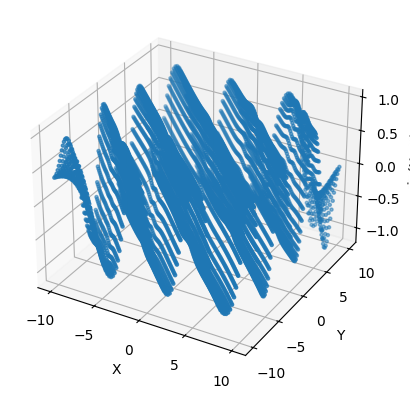

In [14]:
import numpy as np
import matplotlib.pyplot as plt


# paramètres d'entraînement
nb_epoch = 500
taille_de_batch = 1000
prop_test = 0 # proportion de données d'entraînement dans les données complètes
erreur_ent = []
erreur_test = []
f_acti = tanh
df_acti = dtanh


# génération des données
nb_donnees = 100 # **2
x = np.linspace(-10,10,nb_donnees) # ensemble des données
y = np.linspace(-10,10,nb_donnees)
x1, y1 = np.meshgrid(x, y)
x = np.reshape(x1, (x1.size,))
y = np.reshape(y1, (y1.size,))



lot_ent, test = lots_donnees_aleat(prop_test, taille_de_batch, x, y, np.sin(x+y))
lot_ent_xy = lot_ent[:,:,0:2]
lot_ent_sinx = lot_ent[:,:,2:3]
test_xy = test[:,0:2]
test_sinx = test[:,2:3]

# définition du réseau
net = Reseau(
    1,
    Couche(2,20,f_acti, df_acti),
    Couche(20,10,f_acti, df_acti),
    Couche(10,1,Id, dId)
)
net.lr = 0.01


# Entraînement
for epoch in range(nb_epoch): # EPOCH
    for batch in range(lot_ent.shape[0]): # BATCH
        # entraînement
        net.pass_forward(lot_ent_xy[batch])
        erreur_ent.append(net.loss(lot_ent_sinx[batch]))
        net.back_propagation(np.sin(lot_ent_sinx[batch]))



z_pred = net.pass_forward(np.concatenate([x1.flatten().reshape((x1.size,1)),y1.flatten().reshape((y1.size,1))], axis=1)) # résultat du réseau

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    x1.flatten().reshape((x1.size,1)),y1.flatten().reshape((y1.size,1)),
    z_pred,
    marker="."
)

# Étiqueter les axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('sin(X+Y)')

# Afficher le graphique
plt.show()

Les seuls paramètres qu'on modifie sont le nombre d'entrées du réseau, le nombre de données et le nombre d'epoch qu'on augmente à $500$.

On observe là aussi de bons résultats en retrouvant la forme de la fonction sin(x+y).

On peut faire l'inverse et donner une entrée et deux sorties au réseau. On apprendra donc deux fonctions en même temps au réseau. On choisit les fonctions sinus et tangente hyperbolique.

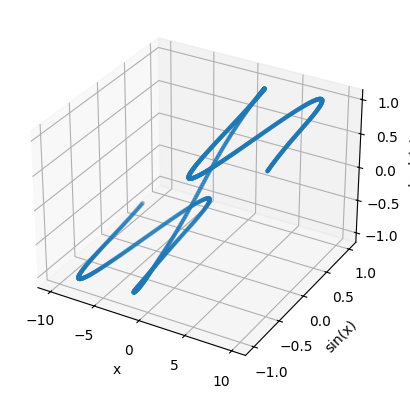

In [15]:
import numpy as np
import matplotlib.pyplot as plt


# paramètres d'entraînement
nb_epoch = 500
taille_de_batch = 100
prop_test = 0 # proportion de données d'entraînement dans les données complètes
erreur_ent = []
erreur_test = []
f_acti = tanh
df_acti = dtanh


# génération des données
nb_donnees = 1000
x = np.linspace(-10,10,nb_donnees) # ensemble des données

# séparation des lots d'entraînement et de test
lot_ent, test = lots_donnees_aleat(prop_test, taille_de_batch, x, np.sin(x), np.tanh(x))
lot_ent_x = lot_ent[:,:,0:1]
lot_ent_sinx_tanh = lot_ent[:,:,1:3]
test_x = test[:,0:1]
test_sinx_tanh = test[:,1:3]

# définition du réseau
net = Reseau(
    1,
    Couche(1,20,f_acti, df_acti),
    Couche(20,10,f_acti, df_acti),
    Couche(10,2,Id, dId)
)
net.lr = 0.01


# Entraînement
for epoch in range(nb_epoch): # EPOCH
    for batch in range(lot_ent.shape[0]): # BATCH
        # entraînement
        net.pass_forward(lot_ent_x[batch])
        erreur_ent.append(net.loss(lot_ent_sinx_tanh[batch]))
        net.back_propagation(lot_ent_sinx_tanh[batch])


# calcul de l'erreur moyenne par epoch
erreur_ent = np.array(erreur_ent)
erreur_ent = np.reshape(erreur_ent, (nb_epoch, int(len(erreur_ent)/nb_epoch)))
erreur_ent = np.sum(erreur_ent, axis=1)/nb_epoch


# PLOT
# calcul du résultat attendu
x = np.reshape(x, (x.size,1))
y_pred = net.pass_forward(x) # résultat du réseau

# Affichage des résultats
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    x.flatten(), y_pred[:,0], y_pred[:,1],
    marker="."
)
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
ax.set_zlabel("tanh(x)")
plt.show()

On retrouve cette fois aussi un bon résultat.

Sur l'axe x, on représente les valeurs de x dans l'intervalle $[-10,10]$, et sur l'axe y, sin(x). Si on se place dans le plan $(x,y)$, on retrouve la forme de la fonction sinus.

Sur l'axe z, on représente les valeurs de tanh(x). On voit que si l'on se place dans le plan $(x,z)$, on retrouve la forme de la fonction tangente hyperbolique.

On pourrait aussi effectuer d'autres changements comme par exemple classer les données régulièrement dans les batch plutôt qu'aléatoirement, ou modifier le nombre de couches ou de neurones.

### Conclusion

Les différents tests du réseau montrent que son efficacité dépend de ses paramètres, et que si l'un d'eux est modifiés, les autres doivent l'être aussi. Par ailleurs, on a montré que le réseau est efficace pour apprendre avec plusieurs entrées ou sorties à la fois.

Le réseau est donc fonctionnel et efficace.